In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

c:\Users\Dell\LangGraph\env0\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()  # Load environment variables from .env file

True

In [3]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [11]:
parent_llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash', temperature=0.2)
subgraph_llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash', temperature=0.2)

In [12]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}


In [13]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [14]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [15]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

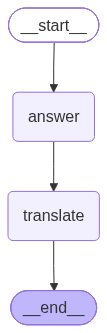

In [16]:
graph = parent_builder.compile()

graph

In [17]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': 'Quantum physics (also known as quantum mechanics or quantum theory) is a fundamental branch of physics that describes the behavior of matter and energy at the atomic and subatomic levels.\n\nHere\'s a breakdown of what that means:\n\n1.  **The World of the Very Small:** While classical physics (like Newton\'s laws) works perfectly for describing objects we see every day (planets, cars, apples), it breaks down when you go to the incredibly tiny scale of atoms, electrons, protons, photons, and other fundamental particles. Quantum physics is the framework needed to understand this microscopic world.\n\n2.  **"Quantum" Means "Packet":** The most fundamental idea is that energy, matter, and light don\'t exist in continuous, smooth quantities, but rather in discrete, indivisible "packets" or "quanta."\n    *   For example, light isn\'t a continuous wave of energy; it comes in tiny packets called **photons**.\n    *   Electrons in an ato